## AUTOMATED PRINTED EQUATION RECOGNIZATION AND LaTeX/MathML CONVERSION FROM IMAGES

### IMPORT LIBRARIES

In [1]:
import re
import os
import cv2
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from collections import defaultdict
from PIL import Image, ImageEnhance
from tqdm import tqdm

### IMPORTING DATASET AND CHECKING FILES

In [2]:
# Define file paths
dataset_dir = r"C:\Users\gurpr\final_six_months_project\dataset"
image_dir = os.path.join(dataset_dir, "formula_images")

train_csv = os.path.join(dataset_dir, "im2latex_train.csv")
val_csv = os.path.join(dataset_dir, "im2latex_validate.csv")
test_csv = os.path.join(dataset_dir, "im2latex_test.csv")

# Load CSVs
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

# Print dataset sizes
print(f"Train Samples: {len(train_df)}")
print(f"Validation Samples: {len(val_df)}")
print(f"Test Samples: {len(test_df)}")

# Check if all images exist
def check_images_exist(df, split_name):
    missing_images = [img for img in df["image"] if not os.path.exists(os.path.join(image_dir, img))]
    
    if missing_images:
        print(f"{len(missing_images)} missing images in {split_name} set!")
        print("Example missing images:", missing_images[:5])
    else:
        print(f"All images exist for {split_name} set!")

# Run the check for all splits
check_images_exist(train_df, "Train")
check_images_exist(val_df, "Validation")
check_images_exist(test_df, "Test")

Train Samples: 75243
Validation Samples: 8365
Test Samples: 10279
All images exist for Train set!
All images exist for Validation set!
All images exist for Test set!


### CHECKING FOR DUPLICATES WITHIN CSVs

In [3]:
# Rename columns for clarity
train_df.columns = ["formula", "image"]
val_df.columns = ["formula", "image"]
test_df.columns = ["formula", "image"]

# Step 1: Check for duplicates **within** each split
def check_internal_duplicates(df, split_name):
    duplicates = df[df.duplicated(keep=False)]
    duplicate_count = len(duplicates) // 2  # Each duplicate appears twice
    print(f"{split_name} - Internal Duplicates: {duplicate_count}")

    if not duplicates.empty:
        print(f"{split_name} Duplicate Samples:")
        print(duplicates.head(10))  # Display first 10 duplicates for reference
        print("-" * 80)

check_internal_duplicates(train_df, "Train")
check_internal_duplicates(val_df, "Validation")
check_internal_duplicates(test_df, "Test")

# Step 2: Check for duplicates **across** splits
def check_cross_split_duplicates(df1, df2, split1_name, split2_name):
    merged_df = df1.merge(df2, on=["formula", "image"], how="inner")
    duplicate_count = len(merged_df)
    
    print(f"{split1_name} ↔ {split2_name} Overlap: {duplicate_count}")

    if not merged_df.empty:
        print(f"{split1_name} ↔ {split2_name} Duplicate Samples:")
        print(merged_df.head(10))  # Display first 10 duplicates
        print("-" * 80)

check_cross_split_duplicates(train_df, val_df, "Train", "Validation")
check_cross_split_duplicates(train_df, test_df, "Train", "Test")
check_cross_split_duplicates(val_df, test_df, "Validation", "Test")

Train - Internal Duplicates: 0
Validation - Internal Duplicates: 0
Test - Internal Duplicates: 0
Train ↔ Validation Overlap: 0
Train ↔ Test Overlap: 0
Validation ↔ Test Overlap: 0


### CHECKING EMPTY IMAGES

In [4]:
# Paths
output_file = r"C:\Users\gurpr\final_six_months_project\empty_images.txt"

def check_empty_images(image_path):
    """Check if an image is completely empty, black, or white."""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None or img.size == 0:
        return True  # Image is missing or empty

    if np.all(img == 0) or np.all(img == 255):
        return True  # Image is fully black or fully white

    return False  # Image is valid

# Scan all images
empty_images = []
for img_name in os.listdir(image_dir):
    img_path = os.path.join(image_dir, img_name)

    if check_empty_images(img_path):
        empty_images.append(img_name)

# Save results
with open(output_file, "w") as f:
    for img in empty_images:
        f.write(img + "\n")

print(f"Found {len(empty_images)} empty images. Saved list to {output_file}.")

Found 0 empty images. Saved list to C:\Users\gurpr\final_six_months_project\empty_images.txt.


### CHECKING FOR MISSING IMAGES AND EXTRA IMAGES

In [5]:
# Get unique image names
train_images = set(train_df["image"])
val_images = set(val_df["image"])
test_images = set(test_df["image"])
all_referenced_images = train_images | val_images | test_images  # Union of all

# Get actual images in directory
actual_images = set(os.listdir(image_dir))

# Find missing and extra images
missing_images = all_referenced_images - actual_images
extra_images = actual_images - all_referenced_images

print(f"Referenced Images in Splits: {len(all_referenced_images)}")
print(f"Actual Images in folder: {len(actual_images)}")
print(f"Missing Images: {len(missing_images)}")
print(f"Extra Images: {len(extra_images)}")

# Save missing & extra images for review
pd.DataFrame({"missing_images": list(missing_images)}).to_csv("missing_images.txt", index=False)
pd.DataFrame({"extra_images": list(extra_images)}).to_csv("extra_images.txt", index=False)

print("Missing & extra images lists saved!")

Referenced Images in Splits: 93887
Actual Images in folder: 93887
Missing Images: 0
Extra Images: 0
Missing & extra images lists saved!


### PREVIEWING CSVs

In [6]:
# Function to preview CSVs
def preview_csv(file_path, split_name):
    print(f"\n{split_name} - First 5 Lines:")
    df = pd.read_csv(file_path)
    print(df.head())

# Check all CSVs
preview_csv(train_csv, "Train")
preview_csv(val_csv, "Validation")
preview_csv(test_csv, "Test")


Train - First 5 Lines:
                                             formula           image
0  \widetilde \gamma _ { \mathrm { h o p f } } \s...  66667cee5b.png
1  ( { \cal L } _ { a } g ) _ { i j } = 0 , \ \ \...  1cbb05a562.png
2  S _ { s t a t } = 2 \pi \sqrt { N _ { 5 } ^ { ...  ed164cc822.png
3  \hat { N } _ { 3 } = \sum \sp f _ { j = 1 } a ...  e265f9dc6b.png
4  \, ^ { * } d \, ^ { * } H = \kappa \, ^ { * } ...  242a58bc3a.png

Validation - First 5 Lines:
                                             formula           image
0  \int _ { - \epsilon } ^ { \infty } d l \: \mat...  5abbb9b19f.png
1  [ { \bar { K } } _ { a } ^ { - } ( p ) , { \ba...  329a44c373.png
2  E ( v ) = \frac { d } { d t } E ( q ) \; \; \;...  73b51f198b.png
3  { \frac { 1 } { L ^ { 2 } } } \prod _ { i = 1 ...  6331d9e7fd.png
4  x ^ { I } ( \sigma + 2 \pi , \tau ) = x ^ { I ...  91a55d2cb9.png

Test - First 5 Lines:
                                             formula           image
0  \alpha _ { 1 } ^ { r } \

### CREATION OF VOCAB.JSON USING TRAIN SPLIT

In [7]:
# File Paths
vocab_path = "C:/Users/gurpr/final_six_months_project/dataset/vocab.json"

# Load Formulas
def load_formulas(file_path):
    df = pd.read_csv(file_path)
    if "formula" not in df.columns:
        print(f"Skipping {file_path}: 'formula' column not found!")
        return []
    return df["formula"].dropna().tolist()

# Tokenization Function
def tokenize_formula(formula):
    return formula.split()

# Build Vocabulary
def build_vocab(formulas):
    token_counter = Counter()
    for formula in formulas:
        tokens = tokenize_formula(formula)
        token_counter.update(tokens)
    
    vocab_list = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"] + sorted(token_counter.keys(), key=lambda x: -token_counter[x])
    vocab_dict = {token: idx for idx, token in enumerate(vocab_list)}
    return vocab_dict

# Create Vocabulary
all_formulas = load_formulas(train_csv)
vocab = build_vocab(all_formulas)

# Save Vocabulary
with open(vocab_path, "w", encoding="utf-8") as f:
    json.dump(vocab, f, indent=4, ensure_ascii=False)

print(f"Vocabulary Created! Total Tokens: {len(vocab)}")
print(f"Saved at: {vocab_path}")

Vocabulary Created! Total Tokens: 544
Saved at: C:/Users/gurpr/final_six_months_project/dataset/vocab.json


### ENCODING DECODING OF EQUATIONS USING VOCAB.JSON ON TRAIN SPLIT

In [8]:
# Paths
vocab_path = os.path.join(dataset_dir, "vocab.json")
error_log_path = r"C:\Users\gurpr\final_six_months_project\encoding_decoding_errors_train.txt"

# Load vocabulary
with open(vocab_path, "r", encoding="utf-8") as f:
    vocab = json.load(f)
idx_to_token = {v: k for k, v in vocab.items()}  # Reverse mapping

# Count missing tokens
missing_token_counter = defaultdict(int)

# Tokenization function
def tokenize_formula(formula):
    return formula.split()

# Encoding function
def encode_tokens(tokens):
    return [vocab.get(token, 3) for token in tokens]  # 3 = <UNK>

# Decoding function
def decode_tokens(indices):
    return " ".join([idx_to_token.get(idx, "<UNK>") for idx in indices])

# Process dataset
errors = []
total_formulas = 0

for file in ["im2latex_train.csv"]:
    file_path = os.path.join(dataset_dir, file)
    
    # Read CSV file
    try:
        df = pd.read_csv(file_path)
        if 'formula' not in df.columns:
            print(f"Skipping {file}: 'formula' column not found!")
            continue
    except Exception as e:
        print(f"Error reading {file}: {e}")
        continue
    
    # Process each formula with progress bar
    for i, formula in tqdm(enumerate(df['formula']), total=len(df), desc=f"Processing {file}"):
        total_formulas += 1
        
        # Tokenize -> Encode -> Decode
        tokens = tokenize_formula(formula)
        encoded = encode_tokens(tokens)
        decoded = decode_tokens(encoded)
        
        # Check for <UNK> in decoded output
        if "<UNK>" in decoded:
            errors.append(f"Formula {i+1} in {file} contains <UNK> after decoding.\n"
                          f"Original: {formula}\n"
                          f"Tokenized: {tokens}\n"
                          f"Encoded: {encoded}\n"
                          f"Decoded: {decoded}\n"
                          f"{'-'*80}\n")
            
            # Track missing tokens
            for token, idx in zip(tokens, encoded):
                if idx == 3:  # If token is <UNK>
                    missing_token_counter[token] += 1
        
        # Show progress (optional)
        # if i % 1000 == 0:
        #     print(f"Processed {i} formulas...")

# Save errors and missing tokens to file
if errors:
    with open(error_log_path, "w", encoding="utf-8") as f:
        f.writelines(errors)
    print(f"Errors found! Check missing tokens in {error_log_path}")
else:
    print("All formulas encoded & decoded successfully. No missing tokens!")

# Summary
print(f"\nChecked {total_formulas} formulas.")
print(f"Total Errors Logged: {len(errors)}")

# Save missing token summary
missing_token_summary = os.path.join(dataset_dir, "missing_token_summary.txt")
with open(missing_token_summary, "w", encoding="utf-8") as f:
    f.write("Missing Token Summary:\n")
    for token, count in sorted(missing_token_counter.items(), key=lambda x: -x[1]):
        f.write(f"{token}: {count}\n")

print(f"Missing token summary saved to {missing_token_summary}")

Processing im2latex_train.csv: 100%|█████████████████████████████████████████| 75243/75243 [00:00<00:00, 103356.08it/s]

All formulas encoded & decoded successfully. No missing tokens!

Checked 75243 formulas.
Total Errors Logged: 0
Missing token summary saved to C:\Users\gurpr\final_six_months_project\dataset\missing_token_summary.txt


### PREVIEWING FEW ENCODING DECODING SAMPLES

In [9]:
# Create token-to-index and index-to-token mappings
token_to_idx = {token: idx for idx, token in enumerate(vocab)}
idx_to_token = {idx: token for token, idx in token_to_idx.items()}

# Function to tokenize a formula
def tokenize_formula(formula):
    """Tokenizes a LaTeX formula using space-based tokenization."""
    tokens = formula.split()
    tokens = ["<SOS>"] + tokens + ["<EOS>"]
    encoded = [token_to_idx.get(token, 3) for token in tokens]  # 3 = <UNK> index
    return tokens, encoded

# Function to decode a sequence
def decode_sequence(encoded_seq):
    """Decodes a list of token indices back to LaTeX formula."""
    decoded_tokens = [idx_to_token.get(idx, "<UNK>") for idx in encoded_seq]
    decoded_formula = " ".join(decoded_tokens[1:-1])  # Join with space and remove special tokens
    return decoded_formula

# Function to sample and check encoding-decoding
def sample_and_check(csv_path, dataset_name, num_samples=5):
    df = pd.read_csv(csv_path)
    samples = df.sample(num_samples)["formula"].tolist()

    print(f"\n**{dataset_name} Set: Random Samples**")
    for i, formula in enumerate(samples):
        tokens, encoded = tokenize_formula(formula)
        decoded = decode_sequence(encoded)

        print("="*100 + "\n")
        print(f"\n**Sample {i+1}:**")
        print(f"Original: {formula}")
        print(f"Tokenized: {tokens}")
        print(f"Encoded: {encoded}")
        print(f"Decoded: {decoded}")
        print(f"UNKs Present: {'Yes' if 3 in encoded else 'No'}")
        print("="*100 + "\n")

# Dataset paths
datasets = {
    "Train": "C:/Users/gurpr/final_six_months_project/dataset/im2latex_train.csv",
}

# Run for each dataset
for name, path in datasets.items():
    sample_and_check(path, name, num_samples=5)


**Train Set: Random Samples**


**Sample 1:**
Original: \prod _ { j = 1 } ^ { N } ( a - a _ { j } ) = \left\{ \begin{array} { l l } { a ^ { N } G ( 1 / x ^ { 2 r } a ) / G ( 1 / a ) , } & { \quad \mathrm { ~ a ~ l a r g e } , } \\ { A _ { N } F ( a ) / F ( x ^ { 2 r } a ) , } & { \quad \mathrm { ~ a ~ s m a l l } . } \\ \end{array} \right.
Tokenized: ['<SOS>', '\\prod', '_', '{', 'j', '=', '1', '}', '^', '{', 'N', '}', '(', 'a', '-', 'a', '_', '{', 'j', '}', ')', '=', '\\left\\{', '\\begin{array}', '{', 'l', 'l', '}', '{', 'a', '^', '{', 'N', '}', 'G', '(', '1', '/', 'x', '^', '{', '2', 'r', '}', 'a', ')', '/', 'G', '(', '1', '/', 'a', ')', ',', '}', '&', '{', '\\quad', '\\mathrm', '{', '~', 'a', '~', 'l', 'a', 'r', 'g', 'e', '}', ',', '}', '\\\\', '{', 'A', '_', '{', 'N', '}', 'F', '(', 'a', ')', '/', 'F', '(', 'x', '^', '{', '2', 'r', '}', 'a', ')', ',', '}', '&', '{', '\\quad', '\\mathrm', '{', '~', 'a', '~', 's', 'm', 'a', 'l', 'l', '}', '.', '}', '\\\\', '\\end{array}', '\\right.

### ENCODING DECODING OF EQUATIONS USING VOCAB.JSON ON VAL AND TEST SPLIT

In [10]:
error_log_path = r"C:\Users\gurpr\final_six_months_project\encoding_decoding_errors_val_test.txt"

idx_to_token = {v: k for k, v in vocab.items()}  # Reverse mapping

# Count missing tokens
missing_token_counter = defaultdict(int)

# Tokenization function
def tokenize_formula(formula):
    return formula.split()

# Encoding function
def encode_tokens(tokens):
    return [vocab.get(token, 3) for token in tokens]  # 3 = <UNK>

# Decoding function
def decode_tokens(indices):
    return " ".join([idx_to_token.get(idx, "<UNK>") for idx in indices])

# Process dataset
errors = []
total_formulas = 0

for file in ["im2latex_validate.csv", "im2latex_test.csv"]:
    file_path = os.path.join(dataset_dir, file)
    
    # Read CSV file
    try:
        df = pd.read_csv(file_path)
        if 'formula' not in df.columns:
            print(f"Skipping {file}: 'formula' column not found!")
            continue
    except Exception as e:
        print(f"Error reading {file}: {e}")
        continue
    
    # Process each formula with progress bar
    for i, formula in tqdm(enumerate(df['formula']), total=len(df), desc=f"Processing {file}"):
        total_formulas += 1
        
        # Tokenize -> Encode -> Decode
        tokens = tokenize_formula(formula)
        encoded = encode_tokens(tokens)
        decoded = decode_tokens(encoded)
        
        # Check for <UNK> in decoded output
        if "<UNK>" in decoded:
            errors.append(f"Formula {i+1} in {file} contains <UNK> after decoding.\n"
                          f"Original: {formula}\n"
                          f"Tokenized: {tokens}\n"
                          f"Encoded: {encoded}\n"
                          f"Decoded: {decoded}\n"
                          f"{'-'*80}\n")
            
            # Track missing tokens
            for token, idx in zip(tokens, encoded):
                if idx == 3:  # If token is <UNK>
                    missing_token_counter[token] += 1
        
        # Show progress (optional)
        # if i % 1000 == 0:
        #     print(f"Processed {i} formulas...")

# Save errors and missing tokens to file
if errors:
    with open(error_log_path, "w", encoding="utf-8") as f:
        f.writelines(errors)
    print(f"Errors found! Check missing tokens in {error_log_path}")
else:
    print("All formulas encoded & decoded successfully. No missing tokens!")

# Summary
print(f"\nChecked {total_formulas} formulas.")
print(f"Total Errors Logged: {len(errors)}")

# Save missing token summary
missing_token_summary = r"C:\Users\gurpr\final_six_months_project\missing_token_summary.txt"
with open(missing_token_summary, "w", encoding="utf-8") as f:
    f.write("Missing Token Summary:\n")
    for token, count in sorted(missing_token_counter.items(), key=lambda x: -x[1]):
        f.write(f"{token}: {count}\n")

print(f"Missing token summary saved to {missing_token_summary}")

Processing im2latex_test.csv: 100%|███████████████████████████████████████████| 10279/10279 [00:00<00:00, 81829.63it/s]

Errors found! Check missing tokens in C:\Users\gurpr\final_six_months_project\encoding_decoding_errors_val_test.txt

Checked 18644 formulas.
Total Errors Logged: 19
Missing token summary saved to C:\Users\gurpr\final_six_months_project\missing_token_summary.txt


### CREATION OF DATASET_WITH_SEQUENCES.JSON USING WHOLE DATASET

In [11]:
# File paths
dataset_dir = "C:/Users/gurpr/final_six_months_project/dataset/"
output_path = dataset_dir + "dataset_with_sequences.json"
vocab_path = dataset_dir + "vocab.json"

# Load vocabulary
with open(vocab_path, "r", encoding="utf-8") as f:
    token_to_index = json.load(f)

# Datasets to process
csv_files = [
    "im2latex_train.csv",
    "im2latex_validate.csv",
    "im2latex_test.csv"
]

# Function to tokenize formula using space-based tokenization
def tokenize_formula(formula):
    tokens = formula.split()
    tokens = ["<SOS>"] + tokens + ["<EOS>"]  # Add start & end tokens
    token_ids = [token_to_index.get(token, token_to_index["<UNK>"]) for token in tokens]
    return token_ids

# Process datasets
dataset_sequences = []
for csv_file in csv_files:
    file_path = dataset_dir + csv_file
    split_name = csv_file.split('.')[0]  # e.g., "im2latex_train" -> "train"
    print(f"Processing: {csv_file}")

    # Read CSV
    df = pd.read_csv(file_path)

    # Ensure necessary columns exist
    if "image" not in df.columns or "formula" not in df.columns:
        print(f"Skipping {csv_file}: Required columns missing!")
        continue

    # Process each formula
    for _, row in tqdm(df.iterrows(), total=len(df)):
        image = row["image"]
        formula = row["formula"]
        token_ids = tokenize_formula(formula)

        dataset_sequences.append({
            "image": image,
            "formula": formula,
            "token_ids": token_ids,
            "split": split_name  # Add split identifier
        })

# Save JSON file
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(dataset_sequences, f, indent=4)

print(f"Dataset saved at: {output_path}")
print(f"Total Samples Processed: {len(dataset_sequences)}")

Processing: im2latex_train.csv


100%|█████████████████████████████████████████████████████████████████████████| 75243/75243 [00:03<00:00, 20091.42it/s]


Processing: im2latex_validate.csv


100%|███████████████████████████████████████████████████████████████████████████| 8365/8365 [00:00<00:00, 17158.04it/s]


Processing: im2latex_test.csv


100%|█████████████████████████████████████████████████████████████████████████| 10279/10279 [00:00<00:00, 19814.54it/s]


Dataset saved at: C:/Users/gurpr/final_six_months_project/dataset/dataset_with_sequences.json
Total Samples Processed: 93887


### CHANGING .PNG TO .NPY IN DATASET_WITH_SEQUENCES.JSON

In [12]:
# Paths
dataset_dir = "C:/Users/gurpr/final_six_months_project/dataset/"
sequences_path = dataset_dir + "dataset_with_sequences.json"
updated_sequences_path = dataset_dir + "dataset_with_sequences.json"

# Load the dataset
with open(sequences_path, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Update image extensions from .png to .npy
for entry in dataset:
    entry["image"] = entry["image"].replace(".png", ".npy")

# Save updated dataset
with open(updated_sequences_path, "w", encoding="utf-8") as f:
    json.dump(dataset, f, indent=4)

print(f"Updated dataset saved to {updated_sequences_path}")

Updated dataset saved to C:/Users/gurpr/final_six_months_project/dataset/dataset_with_sequences.json


### ENCODING DECODING OF FEW SAMPLES USING DATASET_WITH_SEQUENCES.JSON

In [13]:
# File paths
dataset_path = "C:/Users/gurpr/final_six_months_project/dataset/dataset_with_sequences.json"
vocab_path = "C:/Users/gurpr/final_six_months_project/dataset/vocab.json"

# Load vocabulary
with open(vocab_path, "r", encoding="utf-8") as f:
    token_to_index = json.load(f)

# Reverse vocab mapping
idx_to_token = {idx: token for token, idx in token_to_idx.items()}

# Load dataset
with open(dataset_path, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Function to decode token sequences
def decode_tokens(token_ids, index_to_token):
    tokens = [index_to_token.get(idx, "<UNK>") for idx in token_ids]
    # Remove <SOS> and <EOS> for fair comparison
    return " ".join(tokens[1:-1])

# Select random samples
num_samples = 5  # Change this to see more examples
samples = random.sample(dataset, num_samples)

# Print original & decoded formulas
for entry in samples:
    image = entry["image"]
    original_formula = entry["formula"]
    token_ids = entry["token_ids"]

    # Decode formula
    decoded_formula = decode_tokens(token_ids, idx_to_token)

    # Compare original vs decoded
    match = "Matched!" if original_formula.strip() == decoded_formula.strip() else "Mismatch!"

    # Print result
    print("="*100)
    print(f"**Image:** {image}")
    print(f"**Original Formula:** {original_formula}")
    print(f"**Token IDs:** {token_ids}")
    print(f"**Decoded Formula:** {decoded_formula}")
    print(f"**Comparison:** Original = Decoded? ➝ {match}")
    print("="*100 + "\n")

**Image:** 5230f91569.npy
**Original Formula:** E _ { 8 } \perp E _ { 8 } \perp { \cal U } \perp { \cal U } \perp { \cal U } ,
**Token IDs:** [1, 98, 6, 5, 140, 4, 196, 98, 6, 5, 140, 4, 196, 5, 55, 117, 4, 196, 5, 55, 117, 4, 196, 5, 55, 117, 4, 14, 2]
**Decoded Formula:** E _ { 8 } \perp E _ { 8 } \perp { \cal U } \perp { \cal U } \perp { \cal U } ,
**Comparison:** Original = Decoded? ➝ Matched!

**Image:** 12e7fc19b4.npy
**Original Formula:** { x _ { S E } = { \frac { - 1 } { \beta - \alpha } } \operatorname { l o g } { \frac { A { \alpha } ^ { 2 } } { B { \beta } ^ { 2 } } } }
**Token IDs:** [1, 5, 19, 6, 5, 62, 98, 4, 11, 5, 15, 5, 13, 12, 4, 5, 63, 13, 33, 4, 4, 72, 5, 41, 91, 44, 4, 5, 15, 5, 35, 5, 33, 4, 7, 5, 8, 4, 4, 5, 73, 5, 63, 4, 7, 5, 8, 4, 4, 4, 4, 2]
**Decoded Formula:** { x _ { S E } = { \frac { - 1 } { \beta - \alpha } } \operatorname { l o g } { \frac { A { \alpha } ^ { 2 } } { B { \beta } ^ { 2 } } } }
**Comparison:** Original = Decoded? ➝ Matched!

**Image:** 3be

### LOGGING ENCODING DECODING ERRORS USING DATASET_WITH_SEQUENCES.JSON

In [14]:
# File paths
dataset_path = "C:/Users/gurpr/final_six_months_project/dataset/dataset_with_sequences.json"
vocab_path = "C:/Users/gurpr/final_six_months_project/dataset/vocab.json"
error_log_path = "C:/Users/gurpr/final_six_months_project/encoding_decoding_errors_dataset_with_sequences.txt"

# Load vocabulary
with open(vocab_path, "r", encoding="utf-8") as f:
    token_to_idx = json.load(f)

# Reverse vocab mapping
idx_to_token = {idx: token for token, idx in token_to_idx.items()}

# Load dataset
with open(dataset_path, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Function to decode token sequences
def decode_tokens(token_ids, index_to_token):
    tokens = [index_to_token.get(idx, "<UNK>") for idx in token_ids]
    # Remove <SOS> and <EOS> for fair comparison
    return " ".join(tokens[1:-1])

# Process dataset & check encoding-decoding consistency
errors = []
for entry in tqdm(dataset, desc="Checking formulas"):
    image = entry["image"]
    original_formula = entry["formula"]
    token_ids = entry["token_ids"]

    # Decode back to LaTeX
    decoded_formula = decode_tokens(token_ids, idx_to_token)

    # Normalize whitespace for comparison
    original_normalized = ' '.join(original_formula.strip().split())
    decoded_normalized = ' '.join(decoded_formula.strip().split())

    # Compare original & decoded
    if original_normalized != decoded_normalized:
        errors.append({
            "image": image,
            "original_formula": original_formula,
            "decoded_formula": decoded_formula,
            "token_ids": token_ids
        })

# Save errors to file
if errors:
    with open(error_log_path, "w", encoding="utf-8") as f:
        for err in errors:
            f.write(f"Image: {err['image']}\n")
            f.write(f"Original: {err['original_formula']}\n")
            f.write(f"Decoded: {err['decoded_formula']}\n")
            f.write(f"Token IDs: {err['token_ids']}\n")
            f.write("="*80 + "\n")

    print(f"Found {len(errors)} mismatched formulas!")
    print(f"Errors saved in: {error_log_path}")
else:
    print("All formulas encoded & decoded correctly. No mismatches found!")

Checking formulas: 100%|█████████████████████████████████████████████████████| 93887/93887 [00:00<00:00, 124506.41it/s]

Found 19 mismatched formulas!
Errors saved in: C:/Users/gurpr/final_six_months_project/encoding_decoding_errors_dataset_with_sequences.txt


### SPLITING DATASET_WITH_SEQUENCES.JSON INTO TRAIN, VAL & TEST

In [15]:
# File paths
dataset_dir = "C:/Users/gurpr/final_six_months_project/dataset/"
input_path = dataset_dir + "dataset_with_sequences.json"
train_path = dataset_dir + "train_dataset.json"
val_path = dataset_dir + "val_dataset.json"
test_path = dataset_dir + "test_dataset.json"

# Load the dataset
with open(input_path, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Split the dataset
train_data = [entry for entry in dataset if entry["split"] == "im2latex_train"]
val_data = [entry for entry in dataset if entry["split"] == "im2latex_validate"]
test_data = [entry for entry in dataset if entry["split"] == "im2latex_test"]

# Save each split to a separate file
with open(train_path, "w", encoding="utf-8") as f:
    json.dump(train_data, f, indent=4)

with open(val_path, "w", encoding="utf-8") as f:
    json.dump(val_data, f, indent=4)

with open(test_path, "w", encoding="utf-8") as f:
    json.dump(test_data, f, indent=4)

# Print summary
print(f"Train dataset saved to {train_path} with {len(train_data)} samples")
print(f"Validation dataset saved to {val_path} with {len(val_data)} samples")
print(f"Test dataset saved to {test_path} with {len(test_data)} samples")

Train dataset saved to C:/Users/gurpr/final_six_months_project/dataset/train_dataset.json with 75243 samples
Validation dataset saved to C:/Users/gurpr/final_six_months_project/dataset/val_dataset.json with 8365 samples
Test dataset saved to C:/Users/gurpr/final_six_months_project/dataset/test_dataset.json with 10279 samples


### PREPROCESSING IMAGES FOR TRAINING

In [16]:
# Define paths
image_folder = "C:/Users/gurpr/final_six_months_project/dataset/formula_images"  # Change to your dataset path
output_folder = "C:/Users/gurpr/final_six_months_project/dataset/processed_images"  # Change to save processed images

os.makedirs(output_folder, exist_ok=True)  # Create output folder if not exists

# 🔹 Target image size
IMG_HEIGHT, IMG_WIDTH = 160, 1024

def process_image(image_path, save_path):
    """ Load, preprocess, and save the image in float32 format. """
    # Load image (grayscale)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error loading image: {image_path}")
        return

    # 1. Crop extra white spaces
    _, thresh = cv2.threshold(img, 240, 255, cv2.THRESH_BINARY)  # Convert to binary
    coords = cv2.findNonZero(255 - thresh)  # Get bounding box
    x, y, w, h = cv2.boundingRect(coords)
    cropped = img[y:y+h, x:x+w]  # Crop to content

    # 2. Enhance Sharpness & Contrast
    pil_img = Image.fromarray(cropped)
    sharpness = ImageEnhance.Sharpness(pil_img).enhance(2.0)  # Increase sharpness
    contrast = ImageEnhance.Contrast(sharpness).enhance(1.5)  # Boost contrast

    # Convert back to NumPy array
    img = np.array(contrast)

    # 3. Binarization (Optional)
    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4. Resize to target shape
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_AREA)

    # 5. Normalize pixel values (0-1) and Convert to float32
    img = img.astype(np.float32) / 255.0

    # Save as `.npy` file (float32 format)
    np.save(save_path, img)

# Process all images
image_files = os.listdir(image_folder)

for img_name in tqdm(image_files, desc="Processing Images"):
    img_path = os.path.join(image_folder, img_name)
    
    # Change extension to `.npy`
    save_path = os.path.join(output_folder, os.path.splitext(img_name)[0] + ".npy")
    
    process_image(img_path, save_path)

print("All images processed and saved as float32 NumPy arrays!")

Processing Images: 100%|████████████████████████████████████████████████████████| 93887/93887 [05:25<00:00, 288.60it/s]

All images processed and saved as float32 NumPy arrays!


### PREVIEWING FEW PREPROCESSED IMAGES

Image: 4c6481b024.npy
   - Shape: (160, 1024) (Expected: 160x1024)
   - Dtype: float32 (Expected: float32)
   - Min pixel value: 0.0, Max pixel value: 1.0 (Expected: 0 to 1)


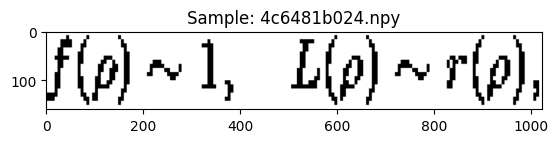

Image: acd83e7ff1.npy
   - Shape: (160, 1024) (Expected: 160x1024)
   - Dtype: float32 (Expected: float32)
   - Min pixel value: 0.0, Max pixel value: 1.0 (Expected: 0 to 1)


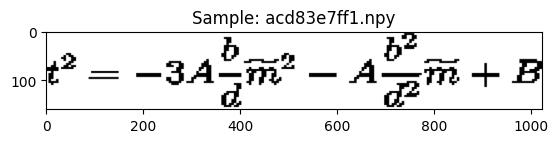

Image: 1e6c6ef538.npy
   - Shape: (160, 1024) (Expected: 160x1024)
   - Dtype: float32 (Expected: float32)
   - Min pixel value: 0.0, Max pixel value: 1.0 (Expected: 0 to 1)


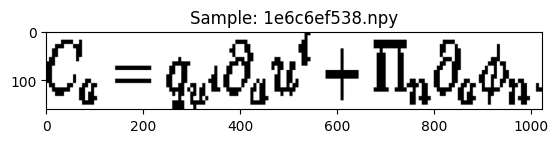

Image: ca126b0b2a.npy
   - Shape: (160, 1024) (Expected: 160x1024)
   - Dtype: float32 (Expected: float32)
   - Min pixel value: 0.0, Max pixel value: 1.0 (Expected: 0 to 1)


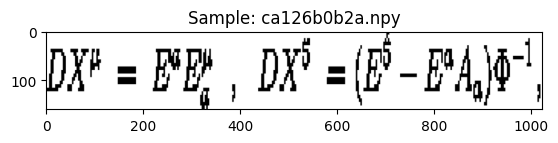

Image: 20e04b4b31.npy
   - Shape: (160, 1024) (Expected: 160x1024)
   - Dtype: float32 (Expected: float32)
   - Min pixel value: 0.0, Max pixel value: 1.0 (Expected: 0 to 1)


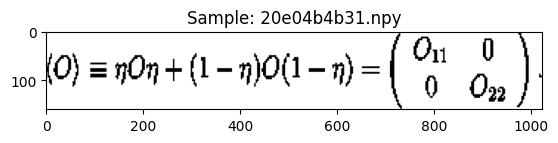

In [17]:
# Define processed image directory
processed_dir = "C:\\Users\\gurpr\\final_six_months_project\\dataset\\processed_images"

# List all .npy files
npy_files = [f for f in os.listdir(processed_dir) if f.endswith(".npy")]

# Pick 5 random images
random_files = random.sample(npy_files, 5)

for file in random_files:
    img_path = os.path.join(processed_dir, file)
    
    # Load image
    img = np.load(img_path)

    # Check shape, dtype, and value range
    print(f"Image: {file}")
    print(f"   - Shape: {img.shape} (Expected: 160x1024)")
    print(f"   - Dtype: {img.dtype} (Expected: float32)")
    print(f"   - Min pixel value: {img.min()}, Max pixel value: {img.max()} (Expected: 0 to 1)")
    
    # Show image
    plt.imshow(img, cmap="gray")
    plt.title(f"Sample: {file}")
    plt.show()

### ANALYZING SEQUENCE LENGTH

Min length: 3
Max length: 152
Mean length: 58.81
Median length: 53.0
25th percentile: 38.0
75th percentile: 75.0


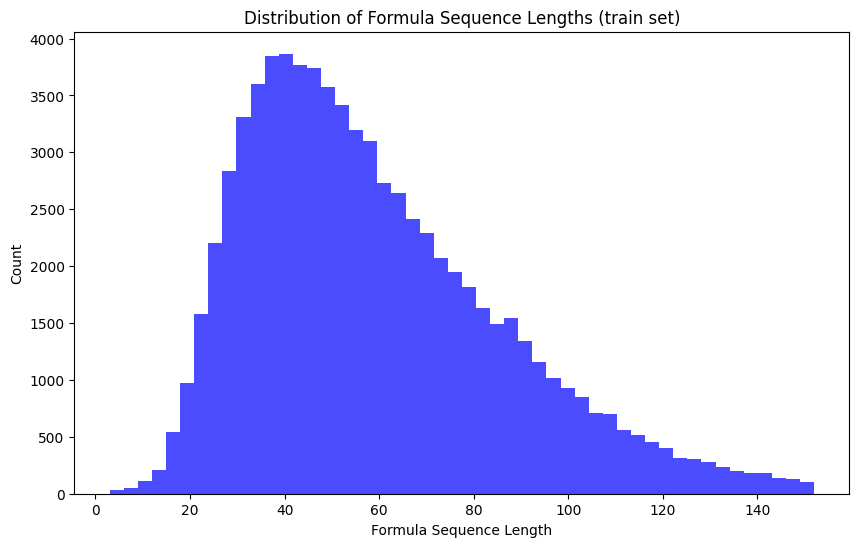

In [18]:
# Load your dataset
with open("C:/Users/gurpr/final_six_months_project/dataset/dataset_with_sequences.json", "r") as f:
    dataset = json.load(f)

# Only analyze train split
lengths = [len(entry["token_ids"]) for entry in dataset if entry["split"] == "im2latex_train"]

print(f"Min length: {np.min(lengths)}")
print(f"Max length: {np.max(lengths)}")
print(f"Mean length: {np.mean(lengths):.2f}")
print(f"Median length: {np.median(lengths)}")
print(f"25th percentile: {np.percentile(lengths, 25)}")
print(f"75th percentile: {np.percentile(lengths, 75)}")

plt.figure(figsize=(10,6))
plt.hist(lengths, bins=50, color='blue', alpha=0.7)
plt.xlabel("Formula Sequence Length")
plt.ylabel("Count")
plt.title("Distribution of Formula Sequence Lengths (train set)")
plt.show()

### CHECKING TOKEN FREQUENCY/DISTRIBUTION


im2latex_train set:
Most common tokens: [(4, 712581), (5, 712577), (6, 230453), (7, 197322), (8, 120486), (9, 114182), (10, 114028), (11, 91399), (12, 90122), (13, 83471)]
Least common tokens: [(543, 1), (542, 1), (541, 1), (540, 1), (539, 1), (538, 1), (537, 1), (536, 1), (535, 1), (534, 1)]


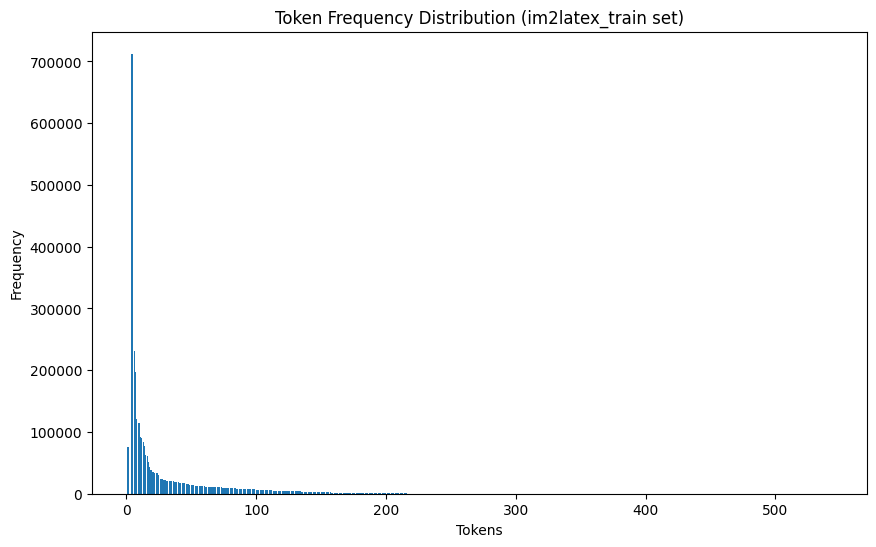


im2latex_validate set:
Most common tokens: [(5, 79112), (4, 79112), (6, 25840), (7, 22277), (8, 13680), (9, 12767), (10, 12748), (11, 10278), (12, 10030), (13, 9561)]
Least common tokens: [(438, 1), (269, 1), (372, 1), (308, 1), (337, 1), (399, 1), (326, 1), (376, 1), (284, 1), (329, 1)]


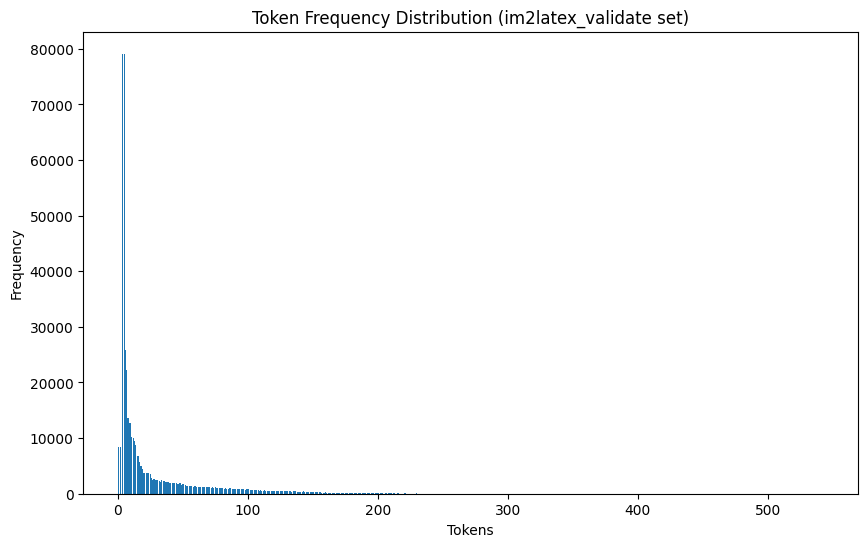


im2latex_test set:
Most common tokens: [(5, 112845), (4, 112845), (6, 36260), (7, 30661), (8, 19449), (9, 17881), (10, 17861), (12, 14755), (13, 13453), (11, 13075)]
Least common tokens: [(403, 1), (423, 1), (516, 1), (376, 1), (388, 1), (321, 1), (443, 1), (537, 1), (491, 1), (360, 1)]


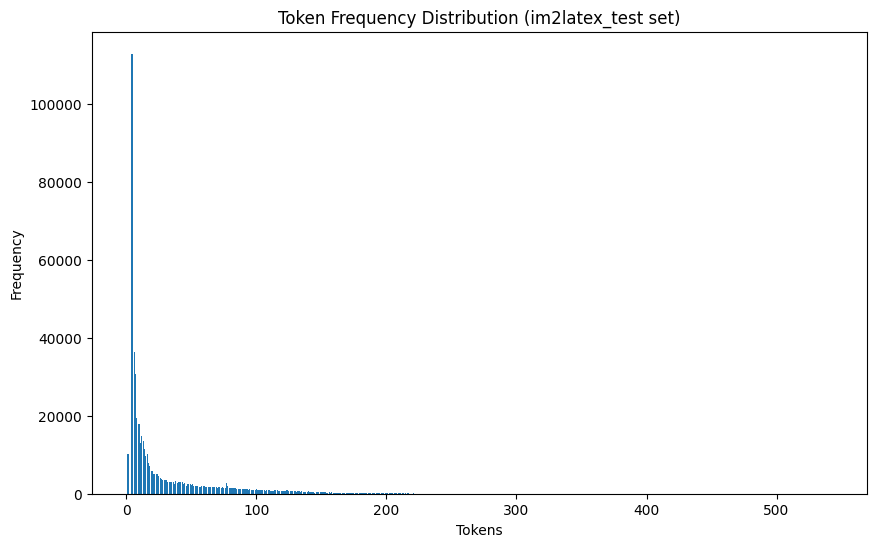

In [19]:
# Load your dataset
with open('C:/Users/gurpr/final_six_months_project/dataset/dataset_with_sequences.json', 'r') as f:
    dataset = json.load(f)

# Function to plot token distribution
def plot_token_distribution(tokens, title):
    token_counts = Counter(tokens)
    plt.figure(figsize=(10, 6))
    plt.bar(token_counts.keys(), token_counts.values())
    plt.xlabel('Tokens')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

# Check and plot for each split
for split_name in ['im2latex_train', 'im2latex_validate', 'im2latex_test']:
    # Extract all tokens from the current split
    split_tokens = []
    for entry in dataset:
        if entry['split'] == split_name:
            split_tokens.extend(entry['token_ids'])
    
    # Display the most common and least common tokens
    print(f"\n{split_name} set:")
    split_counter = Counter(split_tokens)
    print("Most common tokens:", split_counter.most_common(10))
    print("Least common tokens:", split_counter.most_common()[:-11:-1])
    
    # Plot the token distribution
    plot_token_distribution(split_tokens, f'Token Frequency Distribution ({split_name} set)')